# Part 5: Monitoring & Drift Detection

## 5A. Production Data Simulation

In [9]:
import pandas as pd

# dataset from HW2
df = pd.read_csv('df.csv')
df = df.drop(columns=['review_comment_message', 'review_score'])
df.head()

,customer_zip_code_prefix,customer_city,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,seller_zip_code_prefix,seller_city,...,delivery_days,delivery_vs_estimated,is_repeat_customer,seller_state_match,product_volume,is_positive_review,total_order_items,log_price,seller_orders_count,is_delivered
0,3149,sao paulo,8.72,40.0,268.0,4.0,500.0,housewares,9350.0,maua,...,8.0,-8.0,0,1,1976.0,1,1.0,3.433665,53.0,1
1,47813,barreiras,22.76,29.0,178.0,1.0,400.0,perfumery,31570.0,belo horizonte,...,13.0,-6.0,0,0,4693.0,1,1.0,4.784989,110.0,1
2,59296,sao goncalo do amarante,27.20,59.0,468.0,3.0,450.0,pet_shop,31842.0,belo horizonte,...,13.0,-13.0,0,0,6000.0,1,1.0,3.828641,151.0,1
3,98900,santa rosa,16.05,52.0,595.0,1.0,600.0,unknown,5455.0,sao paulo,...,-1.0,0.0,0,0,18375.0,0,1.0,3.929863,41.0,0
4,20780,rio de janeiro,30.53,36.0,450.0,1.0,9000.0,garden_tools,29156.0,cariacica,...,12.0,-9.0,1,0,19656.0,0,2.0,4.605170,200.0,1


In [24]:
numeric_cal = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cal.remove('is_positive_review')
numeric_cal

['customer_zip_code_prefix',
 'freight_value',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'seller_zip_code_prefix',
 'delivery_days',
 'delivery_vs_estimated',
 'is_repeat_customer',
 'seller_state_match',
 'product_volume',
 'total_order_items',
 'log_price',
 'seller_orders_count',
 'is_delivered']

In [25]:
import numpy as np

# Simulation function
def simulate_month(ref_data, month, noise_features, n_samples=3000):
    """Simulate one month of production data with optional drift."""
    np.random.seed(42 + month)

    sample = ref_data.sample(n=n_samples, replace=True,
                             random_state=42 + month).copy()
    sample = sample.reset_index(drop=True)

    # Small noise for ALL months (±5%)
    for col in noise_features:
        noise = np.random.normal(1.0, 0.05, len(sample))
        sample[col] = (sample[col] * noise).round(2)

    # Basic clips
    sample["delivery_days"] = sample["delivery_days"].clip(1, None).round().astype(int)
    sample["freight_value"] = sample["freight_value"].clip(0)
    sample["product_photos_qty"] = sample["product_photos_qty"].clip(0).round().astype(int)
    sample["total_order_items"] = sample["total_order_items"].clip(1).round().astype(int)

    # Drift for months 4-6
    if month >= 4:
        drift_level = month - 3  # 1, 2, 3

        # 1. delivery_days: +2 / +4 / +6 days
        sample["delivery_days"] = (sample["delivery_days"] + drift_level * 2).clip(1)

        # 2. freight_value: +15% / +30% / +50%
        sample["freight_value"] = (sample["freight_value"] * (1 + drift_level * 0.15)).round(2)

        # 3. electronics share: +10 / +15 / +20 percentage points
        non_elec_idx = sample[sample["product_category_name_english"] != "electronics"].index
        n_to_flip = min(int(len(sample) * drift_level * 0.10), len(non_elec_idx))
        if n_to_flip > 0:
            flip_cat_idx = np.random.choice(non_elec_idx, size=n_to_flip, replace=False)
            sample.loc[flip_cat_idx, "product_category_name_english"] = "electronics"

        # 4. Ground truth labels: flip 5% of positives → negative
        pos_idx = sample[sample["is_positive_review"] == 1].index
        n_flip = int(len(pos_idx) * 0.05)
        if n_flip > 0:
            flip_idx = np.random.choice(pos_idx, size=min(n_flip, len(pos_idx)), replace=False)
            sample.loc[flip_idx, "is_positive_review"] = 0

    sample["month"] = month
    return sample


# Generate all 6 months
production = pd.concat(
    [simulate_month(df, m, numeric_cal) for m in range(1, 7)],
    ignore_index=True
)

print(f"Total production records: {len(production)}")
print(f"\nRecords per month: {production['month'].value_counts().sort_index().to_dict()}")

print(f"\n{'Month':<8} {'Positive rate':<18} {'Avg delivery_days':<22} {'Avg freight_value':<22} {'Electronics %'}")
print("-" * 85)
for m in range(1, 7):
    sub = production[production["month"] == m]
    marker = " ← drift starts" if m == 4 else ""
    print(f"  {m:<6} {sub["is_positive_review"].mean():<18.3f} "
          f"{sub['delivery_days'].mean():<22.2f} "
          f"{sub['freight_value'].mean():<22.2f} "
          f"{(sub['product_category_name_english'] == 'electronics').mean():.3f}{marker}")

Total production records: 18000

Records per month: {1: 3000, 2: 3000, 3: 3000, 4: 3000, 5: 3000, 6: 3000}

Month    Positive rate      Avg delivery_days      Avg freight_value      Electronics %
-------------------------------------------------------------------------------------
  1      0.613              12.26                  20.42                  0.024
  2      0.609              12.54                  20.34                  0.024
  3      0.594              12.02                  20.43                  0.021
  4      0.586              14.51                  23.37                  0.126 ← drift starts
  5      0.565              16.33                  26.27                  0.219
  6      0.583              18.33                  30.02                  0.329


In [26]:
# Verify drift is visible in feature means
print("Feature means per month:")
print("=" * 60)
summary = production.groupby('month')[numeric_cal].mean().round(1)
print(summary.to_string())

Feature means per month:
       customer_zip_code_prefix  freight_value  product_name_lenght  product_description_lenght  product_photos_qty  product_weight_g  seller_zip_code_prefix  delivery_days  delivery_vs_estimated  is_repeat_customer  seller_state_match  product_volume  total_order_items  log_price  seller_orders_count  is_delivered
month                                                                                                                                                                                                                                                                                                                       
1                       34315.1           20.4                 49.1                       768.1                 2.2            2261.5                 23065.0           12.3                  -11.2                 0.3                 0.3         16101.2                1.5        4.3                373.1           1.0
2                       

## 5B. Statistical Drift Detection

### PSI (Population Stability Index)

In [27]:
def calculate_psi(reference, current, bins=10):
    """
    Calculate Population Stability Index.

    PSI < 0.1  → No significant drift
    0.1 ≤ PSI < 0.2 → Moderate drift (investigate)
    PSI ≥ 0.2 → Significant drift (action required)
    """
    breakpoints = np.linspace(
        min(reference.min(), current.min()),
        max(reference.max(), current.max()),
        bins + 1
    )
    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    cur_counts = np.histogram(current, bins=breakpoints)[0]

    # Proportions (small constant avoids division by zero)
    ref_pct = ref_counts / len(reference) + 1e-4
    cur_pct = cur_counts / len(current) + 1e-4

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return round(psi, 4)


def interpret_psi(val):
    if val < 0.1: return "Stable"
    elif val < 0.2: return "Moderate"
    else: return "Significant"

# Calculate PSI for each feature × month
psi_features = ['delivery_days', 'freight_value', 'product_weight_g',
                 'product_volume', 'delivery_vs_estimated']

psi_results = {}

for feature in psi_features:
    psi_results[feature] = {}
    for month in range(1, 7):
        month_data = production[production['month'] == month][feature]
        psi_results[feature][month] = calculate_psi(df[feature], month_data)

# Display PSI values
psi_df = pd.DataFrame(psi_results).T
psi_df.columns = [f"Month {m}" for m in range(1, 7)]

print("PSI Results (Reference vs Each Month)")
print("=" * 70)
print(psi_df.round(4).to_string())

# Display interpretation
print("\nPSI Interpretation")
print("=" * 70)
interp_df = psi_df.applymap(interpret_psi)
print(interp_df.to_string())

PSI Results (Reference vs Each Month)
                       Month 1  Month 2  Month 3  Month 4  Month 5  Month 6
delivery_days           0.0013   0.0014   0.0020   0.0161   0.0761   0.1195
freight_value           0.0006   0.0027   0.0038   0.0091   0.0227   0.0786
product_weight_g        0.0029   0.0025   0.0026   0.0050   0.0031   0.0035
product_volume          0.0021   0.0061   0.0025   0.0025   0.0041   0.0023
delivery_vs_estimated   0.0024   0.0024   0.0032   0.0022   0.0048   0.0030

PSI Interpretation
                      Month 1 Month 2 Month 3 Month 4 Month 5   Month 6
delivery_days          Stable  Stable  Stable  Stable  Stable  Moderate
freight_value          Stable  Stable  Stable  Stable  Stable    Stable
product_weight_g       Stable  Stable  Stable  Stable  Stable    Stable
product_volume         Stable  Stable  Stable  Stable  Stable    Stable
delivery_vs_estimated  Stable  Stable  Stable  Stable  Stable    Stable


/tmp/ipykernel_731/640499457.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  interp_df = psi_df.applymap(interpret_psi)


### KS Test (Kolmogorov-Smirnov)

In [28]:
from scipy.stats import ks_2samp

# KS test for each feature × month
print("KS Test Results")
print("=" * 70)

for feature in psi_features:
    print(f"\n{feature}:")
    for month in range(1, 7):
        month_data = production[production['month'] == month][feature]
        stat, pval = ks_2samp(df[feature], month_data)
        sig = "*** SIGNIFICANT" if pval < 0.05 else ""
        print(f"  Month {month}: KS={stat:.4f}, p={pval:.4f} {sig}")

KS Test Results

delivery_days:
  Month 1: KS=0.0424, p=0.0001 *** SIGNIFICANT
  Month 2: KS=0.0424, p=0.0001 *** SIGNIFICANT
  Month 3: KS=0.0424, p=0.0001 *** SIGNIFICANT
  Month 4: KS=0.1308, p=0.0000 *** SIGNIFICANT
  Month 5: KS=0.2538, p=0.0000 *** SIGNIFICANT
  Month 6: KS=0.3690, p=0.0000 *** SIGNIFICANT

freight_value:
  Month 1: KS=0.0310, p=0.0086 *** SIGNIFICANT
  Month 2: KS=0.0357, p=0.0015 *** SIGNIFICANT
  Month 3: KS=0.0290, p=0.0169 *** SIGNIFICANT
  Month 4: KS=0.1779, p=0.0000 *** SIGNIFICANT
  Month 5: KS=0.3455, p=0.0000 *** SIGNIFICANT
  Month 6: KS=0.4261, p=0.0000 *** SIGNIFICANT

product_weight_g:
  Month 1: KS=0.0384, p=0.0005 *** SIGNIFICANT
  Month 2: KS=0.0374, p=0.0007 *** SIGNIFICANT
  Month 3: KS=0.0352, p=0.0018 *** SIGNIFICANT
  Month 4: KS=0.0301, p=0.0119 *** SIGNIFICANT
  Month 5: KS=0.0407, p=0.0002 *** SIGNIFICANT
  Month 6: KS=0.0337, p=0.0032 *** SIGNIFICANT

product_volume:
  Month 1: KS=0.0177, p=0.3380 
  Month 2: KS=0.0267, p=0.0351 *** SIG

## 5C. Performance Monitoring

In [16]:
# Train/test split — stratified to preserve class balance using shared indices
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

X = df.drop(columns=['is_positive_review'])
y = df['is_positive_review']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Train balance: {y_train.mean():.1%} positive | Test balance: {y_test.mean():.1%} positive")


Train: 38393, Test: 9599
Train balance: 61.3% positive | Test balance: 61.3% positive


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['string', 'category', 'object']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', cat_pipeline_tree, cat_cols)
])

In [18]:
# Tuned Random Forest

pipe_tuned = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(pipe_tuned, param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best RF params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

Best RF params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.824


In [19]:
# Tuned RF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
best_rf = grid.best_estimator_

y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]
y_pred_tuned = best_rf.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Features from production data
features = X_train.columns.tolist()

# Generate predictions on all production data
production['pred'] = best_rf.predict(production[features])
production['pred_prob'] = best_rf.predict_proba(production[features])[:, 1]

# Monthly metrics
monthly_metrics = []
for month in range(1, 7):
    mask = production['month'] == month
    y_true = production.loc[mask, 'is_positive_review']
    y_pred = production.loc[mask, 'pred']
    y_prob = production.loc[mask, 'pred_prob']

    monthly_metrics.append({
        'Month': month,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_prob),
    })

metrics_df = pd.DataFrame(monthly_metrics).set_index('Month')

print("Monthly Performance Metrics")
print("=" * 50)
print(metrics_df.round(4).to_string())

# Degradation report
print(f"\nPerformance Drop (Month 1 → Month 6):")
for col in ['Accuracy', 'F1', 'AUC']:
    m1 = metrics_df.loc[1, col]
    m6 = metrics_df.loc[6, col]
    drop = m1 - m6
    pct = (drop / m1) * 100
    print(f"  {col}: {m1:.4f} → {m6:.4f}  (↓{drop:.4f}, {pct:.1f}%)")

Monthly Performance Metrics
       Accuracy      F1     AUC
Month                          
1        0.9163  0.9352  0.9734
2        0.9077  0.9284  0.9714
3        0.9057  0.9250  0.9721
4        0.8503  0.8838  0.9212
5        0.8247  0.8608  0.8961
6        0.8037  0.8468  0.8546

Performance Drop (Month 1 → Month 6):
  Accuracy: 0.9163 → 0.8037  (↓0.1127, 12.3%)
  F1: 0.9352 → 0.8468  (↓0.0884, 9.5%)
  AUC: 0.9734 → 0.8546  (↓0.1189, 12.2%)


## 5D. Monitoring Dashboard

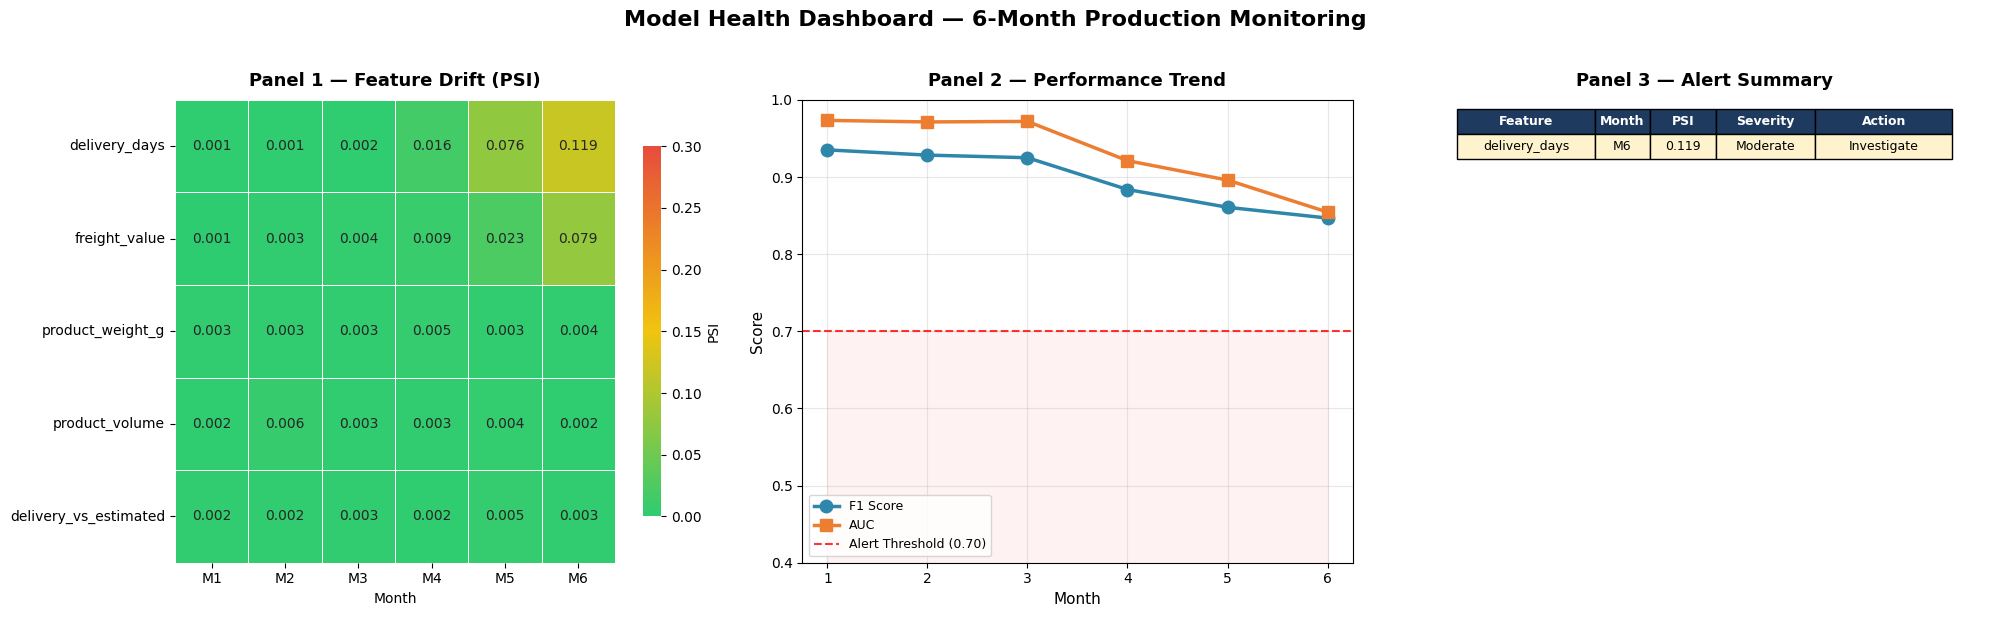

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Model Health Dashboard — 6-Month Production Monitoring",
             fontsize=16, fontweight='bold', y=1.02)

# Panel 1: PSI Heatmap
ax1 = axes[0]
psi_matrix = psi_df.values.astype(float)
colors_list = ['#2ecc71', '#f1c40f', '#e74c3c']
cmap = mcolors.LinearSegmentedColormap.from_list('drift', colors_list, N=256)

sns.heatmap(
    psi_matrix, ax=ax1, annot=True, fmt='.3f', cmap=cmap,
    xticklabels=[f'M{m}' for m in range(1, 7)],
    yticklabels=psi_features,
    vmin=0, vmax=0.3,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'PSI', 'shrink': 0.8}
)
ax1.set_title('Panel 1 — Feature Drift (PSI)', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Month')
ax1.set_ylabel('')

# Panel 2: Performance Trend
ax2 = axes[1]
months = range(1, 7)
ax2.plot(months, metrics_df['F1'],  'o-', color='#2e86ab', lw=2.5, ms=9, label='F1 Score')
ax2.plot(months, metrics_df['AUC'], 's-', color='#ed7d31', lw=2.5, ms=9, label='AUC')
ax2.axhline(y=0.70, color='red', ls='--', lw=1.5, alpha=0.8, label='Alert Threshold (0.70)')
ax2.fill_between(months, 0, 0.70, alpha=0.05, color='red')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Panel 2 — Performance Trend', fontsize=13, fontweight='bold', pad=10)
ax2.set_xticks(range(1, 7))
ax2.set_ylim(0.4, 1.0)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Alert Summary Table
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('Panel 3 — Alert Summary', fontsize=13, fontweight='bold', pad=10)

alerts = []
for feature in psi_features:
    for month in range(1, 7):
        psi_val = psi_results[feature][month]
        if psi_val >= 0.1:  # только Moderate и Significant
            severity = 'Moderate' if psi_val < 0.2 else 'Significant'
            action   = 'Investigate' if psi_val < 0.2 else 'Action Required'
            alerts.append([feature, f'M{month}', f'{psi_val:.3f}', severity, action])

if alerts:
    col_labels = ['Feature', 'Month', 'PSI', 'Severity', 'Action']
    table = ax3.table(
        cellText=alerts, colLabels=col_labels,
        cellLoc='center', loc='upper center',
        colWidths=[0.25, 0.10, 0.12, 0.18, 0.25]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    # Header styling
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#1f3a5f')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Row coloring by severity
    for i, alert in enumerate(alerts, 1):
        color = '#fff3cd' if alert[3] == 'Moderate' else '#f8d7da'
        for j in range(len(col_labels)):
            table[i, j].set_facecolor(color)
else:
    ax3.text(0.5, 0.5, 'No alerts — all features stable',
             ha='center', va='center', fontsize=13, color='green')

plt.tight_layout()
plt.show()

## 5E. Recommendation

Looking at all the monitoring results together, the model is still working but clearly getting worse over time, especially starting from Month 4 when we introduced drift.

The PSI heatmap is almost entirely green, which sounds good, but F1 dropped from 0.935 to 0.847 and AUC from 0.973 to 0.855. This means the model is making more mistakes even though most features look Stable by PSI standards. But one PSI alert we did get - it was `delivery_days` in Month 6 (PSI = 0.119) since we added +6 days to delivery times. The KS test was more sensitive — it caught significant changes in `delivery_days` and `freight_value` earlier from Month 4.

I would set the retraining trigger at PSI >= 0.15 for any key feature or F1 dropping below 0.85. By that rule, model needs to be retrained - F1 hit 0.847 in Month 6. I would include data from Months 4–6 to teach the model the new delivery and freight patterns, and a sample from Months 1–3 to keep it balanced.